In [1]:
from auto_encoder import AutoEncoder
import torch
from configuration import Configuration

c = Configuration()
device = torch.device("cuda")
vqvae = AutoEncoder(device, c).to(device)
vqvae.load_state_dict(torch.load("./model_ema_norm_he-et-al.pth"))

c:\Users\viktor\Documents\liquid\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


<All keys matched successfully>

In [2]:
sum([p.numel() for p in vqvae.parameters()]) / 1_000_000

0.646659

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.041481927..0.8673037].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.110671684..1.016946].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028922157..0.8053127].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028278705..0.849859].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.040969193..1.0671424].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16157708..0.89961874].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [

torch.Size([10, 64, 8, 8])


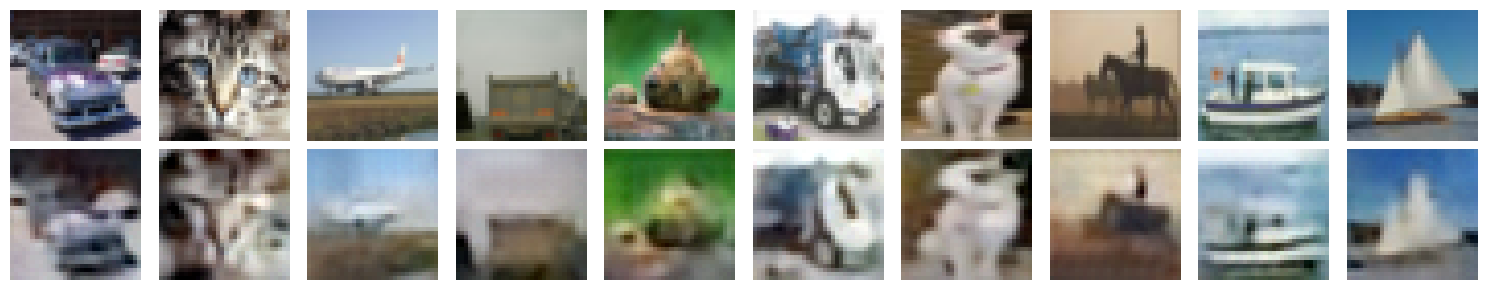

In [5]:

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

def visualize_vae_reconstructions(vae: AutoEncoder, device="cuda" if torch.cuda.is_available() else "cpu"):
    transform = transforms.ToTensor()
    dataset = CIFAR10(root="../../cifar10_data", train=False, transform=transform, download=False)
    loader = DataLoader(dataset, batch_size=10, shuffle=True)

    vae = vae.to(device)
    vae.eval()

    # Get one batch of 10 random images
    images, _ = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        _, recon, _, qe = vae(images)

    print(qe.shape)

    # Move to CPU for visualization
    images = images.cpu()
    recon = recon.cpu()

    # Plot original and reconstructed images
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axes[0, i].imshow(images[i].permute(1, 2, 0))
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].permute(1, 2, 0))
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
    plt.tight_layout()
    plt.show()

visualize_vae_reconstructions(vqvae)